### Step 14 — Baseline Modeling

In this step, we train our first machine learning models to predict churn.

Objectives:
- Validate whether our features are meaningful
- Establish baseline performance
- Detect overfitting or underfitting
- Understand model behavior

We start with simple models:
- Logistic Regression
- Decision Tree

These models help us evaluate the quality of the dataset before using advanced models.

1. Import Libraries

We import machine learning models and evaluation metrics.

In [182]:
!pip install scikit-learn

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

2. Load Saved Train/Test Data

We load previously saved datasets for modeling.

In [184]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [185]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(68526, 38)
(36463, 38)
(68526,)
(36463,)


In [186]:
X_train.isnull().sum().sum()
X_test.isnull().sum().sum()

np.int64(0)

In [187]:
X_train.columns.equals(X_test.columns)

True

In [188]:
X_train.dtypes

cc_call_ratio                float64
low_engagement               float64
Total_Renewal_Score_New      float64
negative_calls               float64
cc_financial_stress_calls    float64
cc_pricing_issue_calls       float64
cc_platform_issue_calls      float64
email_financial_issue        float64
low_payment_intent_count     float64
tenure_bucket_TB_1-3         float64
tenure_bucket_TB_10+         float64
tenure_bucket_TB_3-5         float64
tenure_bucket_TB_5-10        float64
tenure_bucket_TB_Unknown     float64
Band_band a                  float64
Band_band b                  float64
Band_band c1                 float64
Band_band c2                 float64
Band_band d                  float64
Band_band e                  float64
Band_band f                  float64
Band_band f1                 float64
Band_band f2                 float64
Band_band g                  float64
Band_band h                  float64
Band_band i                  float64
Band_band j                  float64
B

In [189]:
y_train.dtypes

dtype('int64')

##### Logistic Regression

This model serves as the baseline.
It predicts the probability of churn.

In [190]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predictions (Logistic Regression)

In [191]:
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

y_test_prob_lr = lr_model.predict_proba(X_test)[:, 1]

Evaluation (Logistic Regression)

Metrics:
- Accuracy → overall correctness
- Recall → ability to detect churn (important)
- AUC → model discrimination ability

In [192]:
print("=== Logistic Regression ===")

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_lr))

print("AUC Score:", roc_auc_score(y_test, y_test_prob_lr))

=== Logistic Regression ===
Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     32726
           1       0.90      0.03      0.05      3737

    accuracy                           0.90     36463
   macro avg       0.90      0.51      0.50     36463
weighted avg       0.90      0.90      0.86     36463

AUC Score: 0.970622781600428


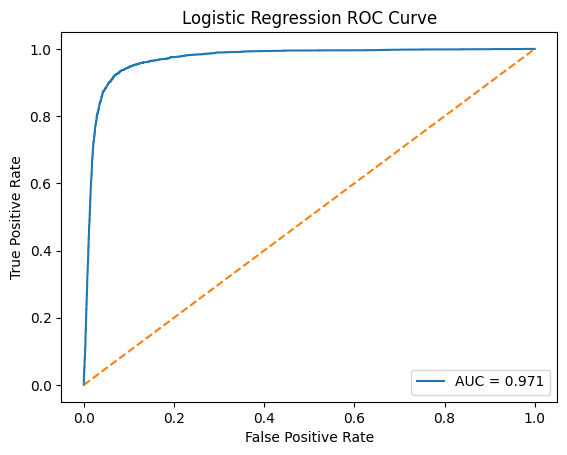

In [193]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_test, y_prob, title):
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_roc_curve(y_test, y_test_prob_lr, "Logistic Regression ROC Curve")



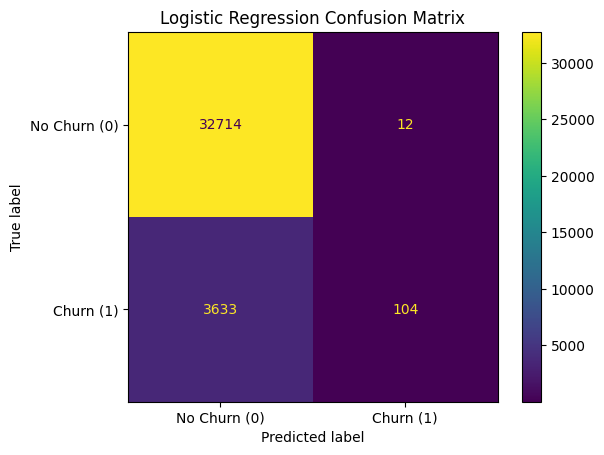

In [194]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_lr,
    display_labels=["No Churn (0)", "Churn (1)"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

##### Logistic Regression with Class Weight

The dataset is imbalanced:
- Non-churn ≈ 90%
- Churn ≈ 10%


In [238]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Predictions

In [239]:
y_prob = lr_model.predict_proba(X_test)[:, 1]

Threshold Comparison

In [240]:
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_prob > t).astype(int)

    print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))

Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     32726
           1       0.68      0.18      0.28      3737

    accuracy                           0.91     36463
   macro avg       0.80      0.58      0.61     36463
weighted avg       0.89      0.91      0.88     36463

Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     32726
           1       0.74      0.33      0.46      3737

    accuracy                           0.92     36463
   macro avg       0.84      0.66      0.71     36463
weighted avg       0.91      0.92      0.91     36463

Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.98   

Threshold Tuning

We reduce the threshold to improve churn recall.

In [241]:
threshold = 0.1 

y_pred = (y_prob > threshold).astype(int)

Evaluation

In [242]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
print("=== Logistic Regression ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("AUC Score:", roc_auc_score(y_test, y_prob))



=== Logistic Regression ===
Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     32726
           1       0.71      0.94      0.81      3737

    accuracy                           0.96     36463
   macro avg       0.85      0.95      0.89     36463
weighted avg       0.96      0.96      0.96     36463

AUC Score: 0.9776821089945726


Confusion Matrix

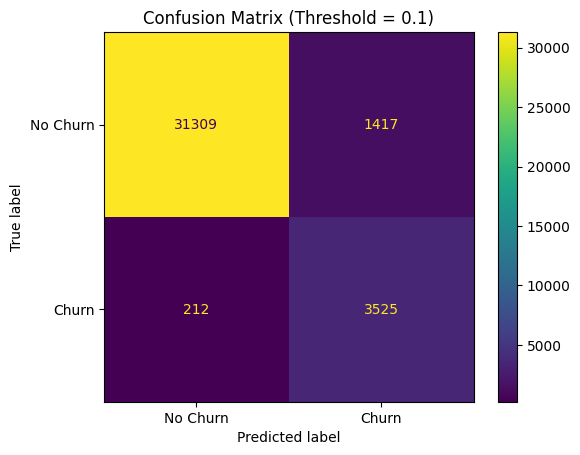

In [243]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()

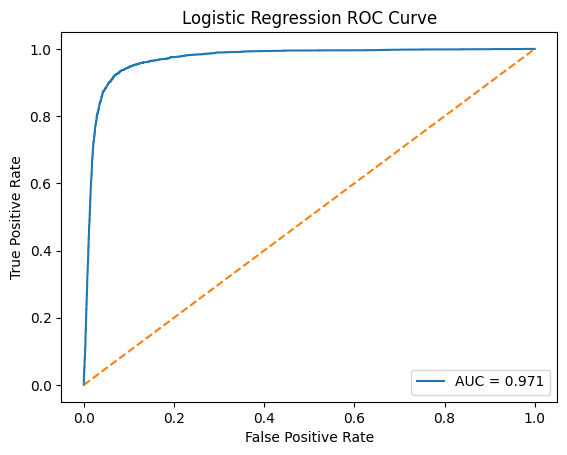

In [244]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_test, y_prob, title):
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_roc_curve(y_test, y_test_prob_lr, "Logistic Regression ROC Curve")



#### Decision Tree

Captures non-linear relationships between features.
Depth is limited to avoid overfitting.

In [202]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [203]:
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

y_test_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [204]:
print("\n=== Decision Tree ===")

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_dt))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_dt))

print("AUC Score:", roc_auc_score(y_test, y_test_prob_dt))


=== Decision Tree ===
Train Accuracy: 0.950704841957797
Test Accuracy: 0.9068644927734965

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     32726
           1       0.81      0.12      0.21      3737

    accuracy                           0.91     36463
   macro avg       0.86      0.56      0.58     36463
weighted avg       0.90      0.91      0.87     36463

AUC Score: 0.6769858297985932


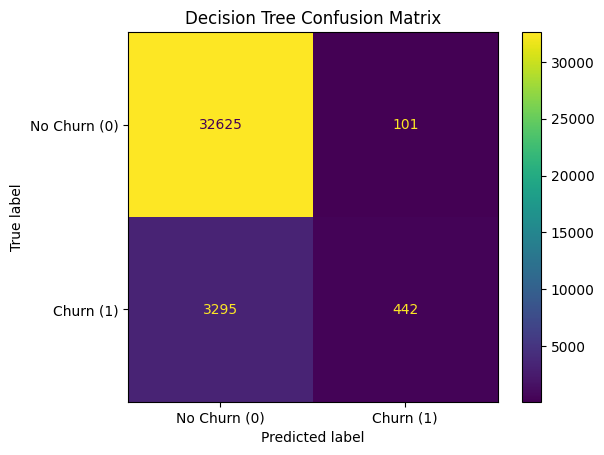

In [205]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_dt,
    display_labels=["No Churn (0)", "Churn (1)"]
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

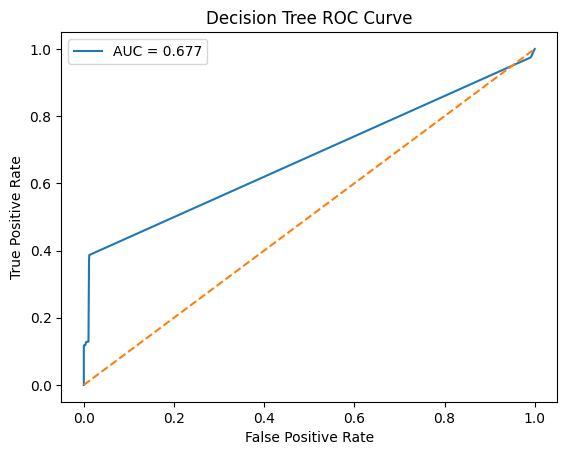

In [206]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_test, y_prob, title):
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()
plot_roc_curve(y_test, y_test_prob_dt, "Decision Tree ROC Curve")


##### Decision Tree with Class Weight

In [207]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

best_f1 = 0
best_config = None
best_model = None
best_threshold = None

# Loop over depths
for depth in [3, 5, 7, 10]:

    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )

    dt_model.fit(X_train, y_train)

    y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

    # Loop over thresholds
    for t in [0.5, 0.4, 0.3, 0.2, 0.1]:

        y_pred_dt = (y_prob_dt > t).astype(int)

        f1 = f1_score(y_test, y_pred_dt)

        # Save best model
        if f1 > best_f1:
            best_f1 = f1
            best_config = depth
            best_threshold = t
            best_model = dt_model
            best_y_pred = y_pred_dt


print("=== Decision Tree Model ===")
print(f"Best Depth: {best_config}")
print(f"Best Threshold: {best_threshold}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nAccuracy:", accuracy_score(y_test, best_y_pred))
print("\nClassification Report:")
print(classification_report(y_test, best_y_pred))

=== Decision Tree Model ===
Best Depth: 5
Best Threshold: 0.1
Best F1 Score: 0.5316

Accuracy: 0.9301757946411431

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     32726
           1       0.85      0.39      0.53      3737

    accuracy                           0.93     36463
   macro avg       0.89      0.69      0.75     36463
weighted avg       0.93      0.93      0.92     36463



In [208]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

best_f1 = 0
best_params = None
best_model = None
best_threshold = None

for depth in [3, 5, 7, 10]:
    for split in [2, 5, 10]:
        for leaf in [1, 2, 4]:

            dt_model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                class_weight='balanced',
                random_state=42
            )

            dt_model.fit(X_train, y_train)

            y_prob = dt_model.predict_proba(X_test)[:, 1]

            for t in [0.5, 0.4, 0.3, 0.2, 0.1]:

                y_pred = (y_prob > t).astype(int)

                f1 = f1_score(y_test, y_pred)

                if f1 > best_f1:
                    best_f1 = f1
                    best_params = (depth, split, leaf)
                    best_threshold = t
                    best_model = dt_model
                    best_y_pred = y_pred


print("=== Decision Tree Model ===")
print(f"Best Params (depth, split, leaf): {best_params}")
print(f"Best Threshold: {best_threshold}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nAccuracy:", accuracy_score(y_test, best_y_pred))
print("\nClassification Report:")
print(classification_report(y_test, best_y_pred))

=== Decision Tree Model ===
Best Params (depth, split, leaf): (5, 2, 2)
Best Threshold: 0.1
Best F1 Score: 0.5327

Accuracy: 0.9302854948852262

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     32726
           1       0.85      0.39      0.53      3737

    accuracy                           0.93     36463
   macro avg       0.89      0.69      0.75     36463
weighted avg       0.93      0.93      0.92     36463



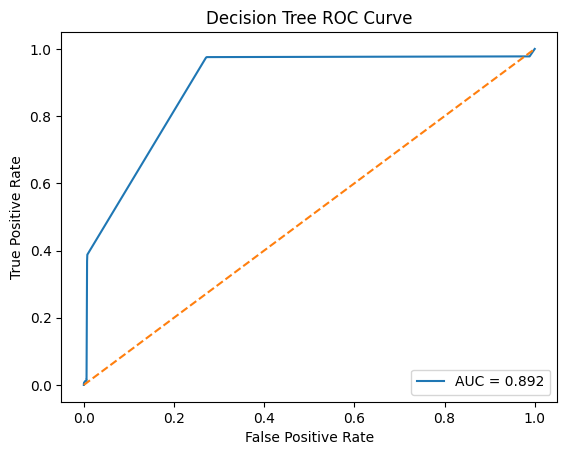

In [209]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities from best model
y_prob_dt = best_model.predict_proba(X_test)[:, 1]

# AUC score
auc_dt = roc_auc_score(y_test, y_prob_dt)

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_dt:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

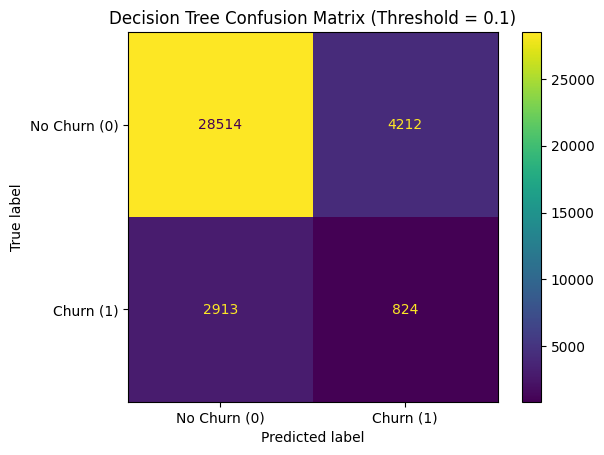

In [210]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=["No Churn (0)", "Churn (1)"]
)

plt.title(f"Decision Tree Confusion Matrix (Threshold = {threshold})")
plt.show()

### Step 16 — Advanced Modeling

In this step, we train advanced ensemble models to improve churn prediction.

Models used:
- XGBoost (Gradient Boosting)
- Random Forest

These models capture complex patterns and interactions between features.

In [211]:
!pip install xgboost

##### XGBoost Model

XGBoost is a powerful boosting algorithm that builds trees sequentially.

It focuses on correcting previous errors and often performs better than other models.

In [212]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight= (y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

d:\INT230\DS_mini_project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:13:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Predictions

In [213]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

Threshold Tuning

In [214]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

for t in [0.5, 0.3, 0.2, 0.1]:
    
    y_pred_xgb = (y_prob_xgb > t).astype(int)

    print(f"\nThreshold: {t}")
    print("Train Accuracy:", accuracy_score(y_train, xgb_model.predict(X_train)))
    print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print(classification_report(y_test, y_pred_xgb))


Threshold: 0.5
Train Accuracy: 0.959679537693722
Test Accuracy: 0.906562817102268
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     32726
           1       0.82      0.11      0.20      3737

    accuracy                           0.91     36463
   macro avg       0.86      0.56      0.57     36463
weighted avg       0.90      0.91      0.87     36463


Threshold: 0.3
Train Accuracy: 0.959679537693722
Test Accuracy: 0.9013520555083235
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     32726
           1       0.59      0.12      0.21      3737

    accuracy                           0.90     36463
   macro avg       0.75      0.56      0.58     36463
weighted avg       0.88      0.90      0.87     36463


Threshold: 0.2
Train Accuracy: 0.959679537693722
Test Accuracy: 0.8836080410278913
              precision    recall  f1-score   support

           0       0.91      0.97      0

##### Hyperparameter Tuning

1.Manual Tuning

In [215]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

for depth in [3, 4, 5]:
    for lr in [0.05, 0.1]:
        for n in [200, 300]:
            
            xgb_model = XGBClassifier(
                max_depth=depth,
                learning_rate=lr,
                n_estimators=n,
                scale_pos_weight=ratio * 2,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric='auc'
            )

            xgb_model.fit(X_train, y_train)

            y_prob = xgb_model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob > 0.1).astype(int)

            print(f"\nDepth={depth}, LR={lr}, Trees={n}")
            print(classification_report(y_test, y_pred))


Depth=3, LR=0.05, Trees=200
              precision    recall  f1-score   support

           0       0.94      0.87      0.91     32726
           1       0.33      0.55      0.41      3737

    accuracy                           0.84     36463
   macro avg       0.64      0.71      0.66     36463
weighted avg       0.88      0.84      0.86     36463


Depth=3, LR=0.05, Trees=300
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     32726
           1       0.20      0.31      0.25      3737

    accuracy                           0.80     36463
   macro avg       0.56      0.59      0.57     36463
weighted avg       0.84      0.80      0.82     36463


Depth=3, LR=0.1, Trees=200
              precision    recall  f1-score   support

           0       0.90      0.86      0.88     32726
           1       0.13      0.19      0.16      3737

    accuracy                           0.79     36463
   macro avg       0.52      0.52      0.5

2. GridSearchCV

In [216]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

params = {
    'max_depth': [3, 4],
    'learning_rate': [0.05],
    'n_estimators': [200, 300],
}

xgb = XGBClassifier(
    scale_pos_weight=ratio * 2,
    random_state=42,
    eval_metric='auc'
)

grid = GridSearchCV(
    xgb,
    param_grid=params,
    scoring='f1',
    cv=2,          # reduced
    n_jobs=1       # VERY IMPORTANT
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [217]:
y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

for t in [0.3, 0.2, 0.1]:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold {t}")
    print(classification_report(y_test, y_pred))


Threshold 0.3
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     32726
           1       0.73      0.22      0.34      3737

    accuracy                           0.91     36463
   macro avg       0.82      0.61      0.65     36463
weighted avg       0.90      0.91      0.89     36463


Threshold 0.2
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     32726
           1       0.52      0.50      0.51      3737

    accuracy                           0.90     36463
   macro avg       0.73      0.73      0.73     36463
weighted avg       0.90      0.90      0.90     36463


Threshold 0.1
              precision    recall  f1-score   support

           0       0.95      0.87      0.90     32726
           1       0.33      0.58      0.42      3737

    accuracy                           0.84     36463
   macro avg       0.64      0.72      0.66     36463
weighted avg       0.88      

##### Final XGBoost Model (Tuned)

The XGBoost model is trained using the best hyperparameters obtained from tuning.

Best Parameters:
- max_depth = 3
- learning_rate = 0.05
- n_estimators = 200

Threshold is adjusted to 0.2 to balance precision and recall.

Evaluation Metrics:
- Train & Test Accuracy
- Precision, Recall, F1-score
- AUC Score
- ROC Curve

In [218]:
# Use best model from GridSearch
xgb_model = grid.best_estimator_

# Predictions
y_train_prob = xgb_model.predict_proba(X_train)[:, 1]
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.2

y_train_pred = (y_train_prob > threshold).astype(int)
y_test_pred = (y_test_prob > threshold).astype(int)

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("=== Final XGBoost Model ===")

print("\nTrain Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

print("AUC Score:", roc_auc_score(y_test, y_test_prob))

=== Final XGBoost Model ===

Train Accuracy: 0.9166593701660684
Test Accuracy: 0.9013246304473027

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     32726
           1       0.52      0.50      0.51      3737

    accuracy                           0.90     36463
   macro avg       0.73      0.73      0.73     36463
weighted avg       0.90      0.90      0.90     36463

AUC Score: 0.8773206914815337


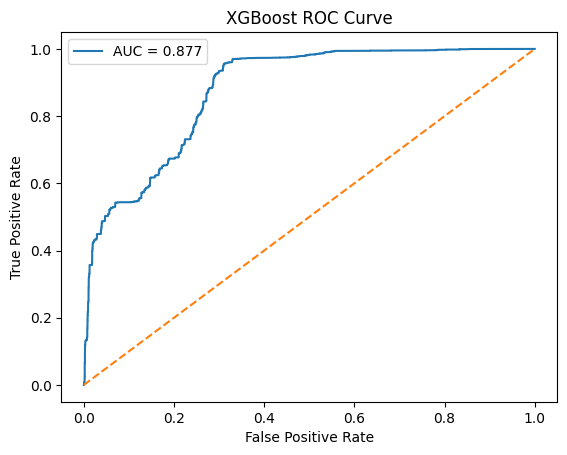

In [219]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_test_prob):.3f}")  
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

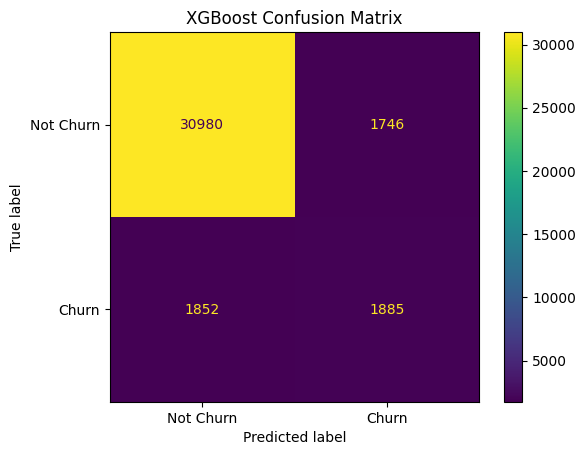

In [220]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test, y_test_pred)
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churn', 'Churn'])
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

##### 🔹 Random Forest Model (Baseline)

Random Forest is trained without hyperparameter tuning.

This serves as a baseline ensemble model.

Evaluation includes:
- Accuracy (Train & Test)
- Precision, Recall, F1-score
- AUC Score

Threshold is adjusted to improve churn detection.

In [221]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

# Train model (no tuning)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predict probabilities
y_train_prob_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Apply threshold
threshold = 0.2

y_train_pred_rf = (y_train_prob_rf > threshold).astype(int)
y_test_pred_rf = (y_test_prob_rf > threshold).astype(int)

#  Accuracy
print("=== Random Forest ===")

print("\nTrain Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))

# Classification report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_rf))

# AUC
auc_rf = roc_auc_score(y_test, y_test_prob_rf)
print("AUC Score:", auc_rf)

=== Random Forest ===

Train Accuracy: 0.9685520824212708
Test Accuracy: 0.8994871513589118

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     32726
           1       0.54      0.14      0.22      3737

    accuracy                           0.90     36463
   macro avg       0.72      0.56      0.58     36463
weighted avg       0.87      0.90      0.87     36463

AUC Score: 0.7045753396757806


Threshold Tuning

In [222]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

# Train model (no tuning)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predict probabilities
y_train_prob_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# tuning threshold
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    
    y_pred_rf = (y_test_prob_rf > t).astype(int)

    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_rf))

#  Accuracy

print("\nTrain Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))

# AUC
auc_rf = roc_auc_score(y_test, y_test_prob_rf)
print("AUC Score:", auc_rf)


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      1.00      0.94     32726
           1       0.00      0.00      0.00      3737

    accuracy                           0.89     36463
   macro avg       0.45      0.50      0.47     36463
weighted avg       0.81      0.89      0.85     36463


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.99      0.95     32726
           1       0.44      0.04      0.08      3737

    accuracy                           0.90     36463
   macro avg       0.67      0.52      0.51     36463
weighted avg       0.85      0.90      0.86     36463


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.99      0.95     32726
           1       0.49      0.09      0.15      3737

    accuracy                           0.90     36463
   macro avg       0.70      0.54      0.55     36463
weighted avg       0.86   

Hyperparameter Tuning

Manual Tuning

In [223]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

best_f1 = 0
best_model = None
best_params = None

for depth in [5, 7, 10]:
    for n in [100, 200]:
        for split in [2, 5]:
            for leaf in [1, 2]:
                
                rf = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    min_samples_split=split,
                    min_samples_leaf=leaf,
                    class_weight='balanced',
                    random_state=42,
                    n_jobs=-1
                )
                
                rf.fit(X_train, y_train)

                y_prob = rf.predict_proba(X_test)[:, 1]
                y_pred = (y_prob > 0.1).astype(int)   # use best threshold

                f1 = f1_score(y_test, y_pred)

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = rf
                    best_params = (depth, n, split, leaf)

print("Best Params:", best_params)
print("Best F1:", best_f1)

Best Params: (5, 200, 5, 1)
Best F1: 0.6540785498489426


In [224]:
rf_model = grid.best_estimator_

y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.1).astype(int)

from sklearn.metrics import accuracy_score

# Train predictions
y_train_pred = (rf_model.predict_proba(X_train)[:, 1] > 0.1).astype(int)

# Test predictions
y_test_pred = (rf_model.predict_proba(X_test)[:, 1] > 0.1).astype(int)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(y_test, y_pred))

Train Accuracy: 0.8765286168753466
Test Accuracy: 0.8358610097907467
              precision    recall  f1-score   support

           0       0.95      0.87      0.90     32726
           1       0.33      0.58      0.42      3737

    accuracy                           0.84     36463
   macro avg       0.64      0.72      0.66     36463
weighted avg       0.88      0.84      0.85     36463



2. GridSearch CV

In [225]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

grid = GridSearchCV(
    rf,
    param_grid=params,
    scoring='f1',
    cv=2,
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [226]:
rf_model = grid.best_estimator_

y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.1).astype(int)

from sklearn.metrics import accuracy_score

# Train predictions
y_train_pred = (rf_model.predict_proba(X_train)[:, 1] > 0.1).astype(int)

# Test predictions
y_test_pred = (rf_model.predict_proba(X_test)[:, 1] > 0.1).astype(int)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_pred))

Train Accuracy: 0.8437381431865277
Test Accuracy: 0.9112250774757974
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     32726
           1       0.55      0.80      0.65      3737

    accuracy                           0.91     36463
   macro avg       0.76      0.86      0.80     36463
weighted avg       0.93      0.91      0.92     36463



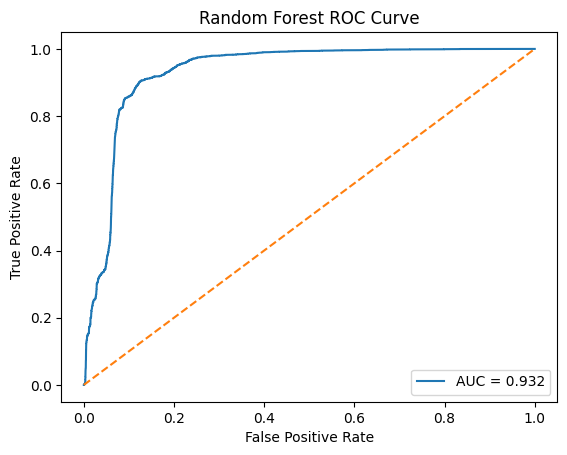

In [227]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

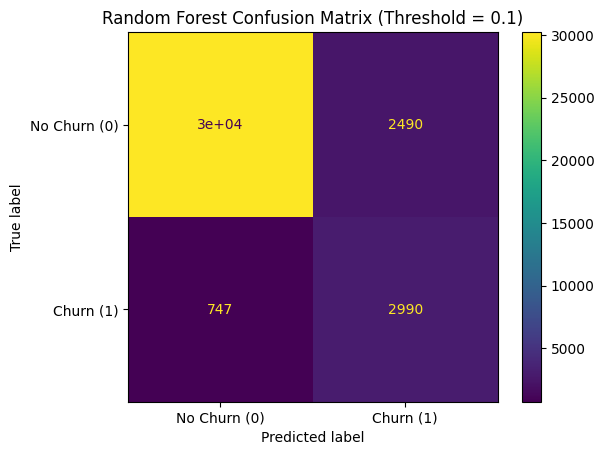

In [228]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Apply threshold
threshold = 0.1
y_pred_rf = (y_prob_rf > threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Churn (0)", "Churn (1)"]
)

plt.title(f"Random Forest Confusion Matrix (Threshold = {threshold})")
plt.show()

### Model Explainability (SHAP)

To understand churn drivers in depth, SHAP (SHapley Additive Explanations)
was used.

SHAP provides:
- Feature importance
- Direction of impact
- Contribution of each feature

This allows us to interpret model predictions accurately.

In [229]:
!pip install shap

In [230]:
import shap

# Create explainer
explainer = shap.Explainer(xgb_model, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)

100%|===================| 36321/36463 [01:32<00:00]        

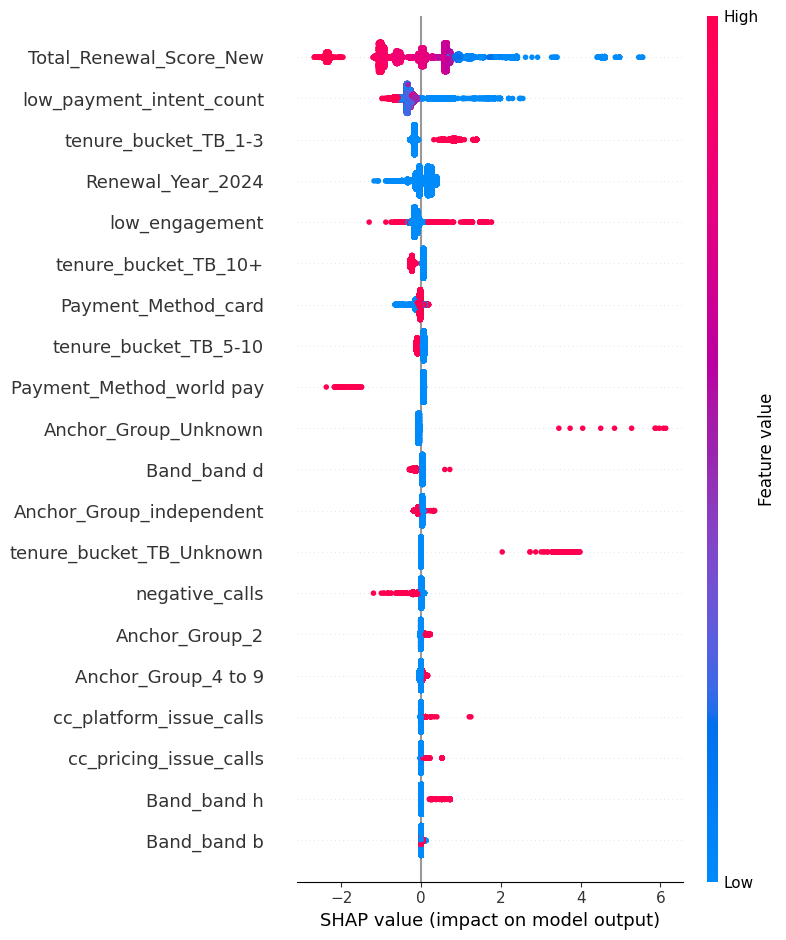

In [231]:
shap.summary_plot(shap_values, X_test)



##### SHAP Summary Plot Interpretation

The SHAP summary plot shows the impact of each feature on churn prediction at an individual customer level. Each point represents a customer. The x-axis shows the SHAP value, indicating whether the feature increases or decreases churn probability. Red indicates high feature values and blue indicates low feature values.

##### Feature-level Insights

**Total_Renewal_Score_New**
Low values strongly increase churn probability, while high values reduce churn.
Customers with low renewal scores are highly likely to churn.
Business should improve renewal experience and provide incentives before renewal.

**low_payment_intent_count**
Higher values increase churn probability.
Customers showing low payment intent are at high risk.
Business should implement early reminders and flexible payment plans.

**tenure_bucket_TB_1-3**
Customers in early tenure stages (1–3 months) have higher churn risk.
New customers are more likely to churn.
Business should focus on onboarding and early engagement strategies.

**Renewal_Year_2024**
Shows variation indicating time-based or seasonal effects in churn behavior.
Churn patterns may vary across different time periods.

**low_engagement**
Higher values increase churn probability.
Customers with low engagement are highly likely to churn.
Business should improve engagement through campaigns, notifications, and personalized communication.

**tenure_bucket_TB_10+**
Higher tenure reduces churn probability.
Long-term customers are more stable and less likely to churn.

**Payment_Method_world pay**
Certain payment methods show higher churn association.
Possible payment friction or usability issues may exist.

**Anchor_Group_Unknown**
Customers with unknown grouping show high churn risk.
These customers may lack proper segmentation or engagement.

**negative_calls**
Higher number of negative interactions increases churn probability.
Customer dissatisfaction is a major driver of churn.
Business should improve support quality and reduce negative experiences.







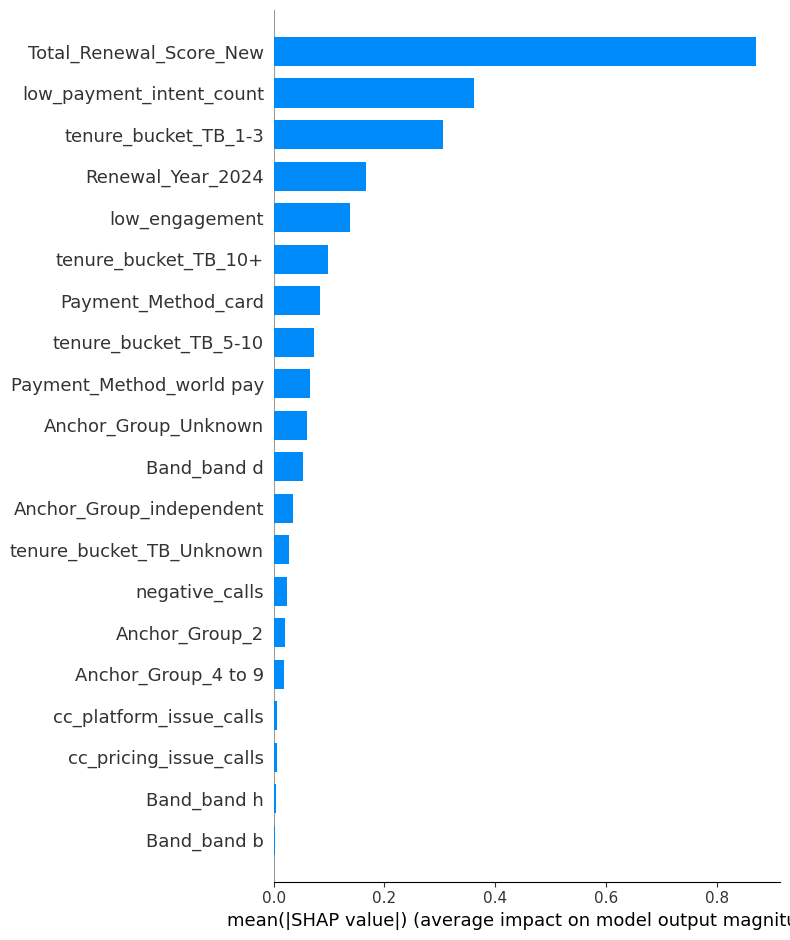

In [232]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

##### SHAP Bar Plot Interpretation

The SHAP bar plot shows the average importance of each feature across all predictions. It does not indicate direction, only the magnitude of influence.

##### Key Insights

**Total_Renewal_Score_New**
The most important feature overall, indicating renewal behavior is the primary driver of churn.

**low_payment_intent_count**
Second most important feature, showing payment behavior strongly influences churn.

**tenure_bucket_TB_1-3**
Early-stage customers contribute significantly to churn.

**Other Important Features**
Low engagement, payment method, tenure buckets, and interaction-related features also contribute meaningfully.


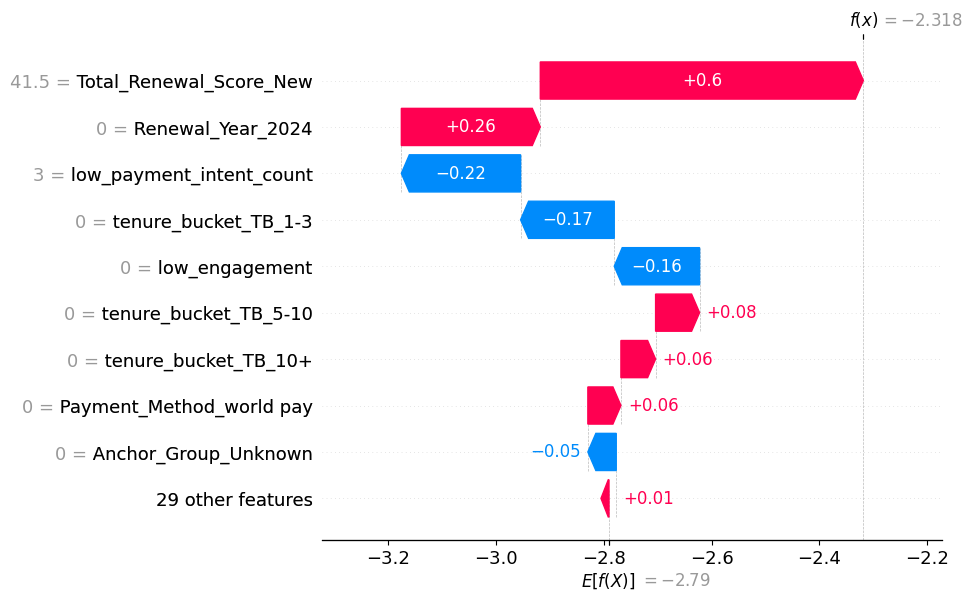

In [233]:
shap.plots.waterfall(shap_values[0])

##### SHAP Individual Prediction (Waterfall Plot)

This plot explains how the model arrived at a prediction for a single customer. It shows how each feature contributes to pushing the prediction toward churn or non-churn.

The baseline value represents the average prediction across all customers. Each feature then adds or subtracts from this baseline to reach the final prediction.

* Red bars increase the prediction value (push towards churn)
* Blue bars decrease the prediction value (push towards non-churn)


##### Interpretation of This Customer

The final prediction value is lower than the baseline, indicating that the model predicts this customer is less likely to churn overall.


##### Feature-level Explanation

**Total_Renewal_Score_New = 41.5 (+0.60)**
This is the strongest contributing feature for this customer.
It significantly increases the prediction value, meaning this feature pushes the model toward predicting churn.

**Renewal_Year_2024 = 0 (+0.26)**
This also increases churn probability moderately.
It indicates that based on the model’s learned patterns, this value contributes to higher churn risk.

**low_payment_intent_count = 3 (−0.22)**
This reduces churn probability.
For this customer, payment intent appears to be relatively stable compared to others.

**tenure_bucket_TB_1-3 = 0 (−0.17)**
This indicates the customer is not in the early tenure bucket.
This reduces churn risk, meaning longer-tenure customers are more stable.

**low_engagement = 0 (−0.16)**
This shows the customer is not classified as low engagement.
Higher engagement reduces churn probability.

**tenure_bucket_TB_5-10 = 0 (+0.08)**
This slightly increases churn probability.
This suggests that customers in other tenure groups may have slightly higher churn risk.

**tenure_bucket_TB_10+ = 0 (+0.06)**
Also slightly increases churn probability.
This indicates the customer is not in the most stable long-tenure group.

**Payment_Method_world pay = 0 (+0.06)**
This contributes slightly to increased churn risk.
It may reflect differences in payment behavior across methods.

**Anchor_Group_Unknown = 0 (−0.05)**
This slightly reduces churn probability.
The customer belongs to a known group, which is generally more stable.

**Other features (+0.01 combined)**
All remaining features together have minimal impact on the prediction.



#### Combined Insights and Business Understanding

From all three SHAP plots, we can clearly understand why customers are churning and what factors are most important.

The same few features keep appearing again and again, which means they are truly important.


##### Simple Understanding

Customers are more likely to churn when:

* Their renewal score is low
* They are not interested in paying or renewing
* They are new customers (first few months)
* They are not engaging much
* They have had negative experiences

At the same time, customers are less likely to churn when:

* They are engaged
* They have been with the company for a long time
* They show good payment behavior


##### What we learned from all plots together

* Renewal score is the biggest factor. If it is low, churn risk is very high
* Payment intent gives an early signal before churn actually happens
* New customers are the most risky group
* Engagement is very important. Less engagement means higher churn
* Bad customer experience directly leads to churn

Also, one important thing is:

Churn is not caused by just one reason. It is a combination of multiple small factors.


##### Business Interpretation

In simple terms, customers leave when:

* They don’t feel connected to the product
* They don’t see value in renewing
* They face issues (payment, support, experience)

Customers stay when:

* They are actively using and engaging
* They have a smooth experience
* They trust the service


##### Recommendations

1. Focus more on new customers
   Make sure they get a good onboarding experience
   Keep them engaged in the first 1–3 months

2. Improve renewal process
   Give reminders, offers, or incentives before renewal

3. Track payment behavior
   If someone is delaying or not interested in paying, reach out early

4. Increase engagement
   Use emails, messages, or offers to keep customers active

5. Improve customer support
   Reduce complaints and fix issues faster


##### Final Thought

Customers don’t leave randomly.
They give signals before leaving.

If the business tracks these signals early, it can reduce churn significantly.


### Logistic Regression Explainability

For Logistic Regression, model coefficients are used for interpretation.

- Positive coefficients increase churn probability
- Negative coefficients decrease churn probability

Since Logistic Regression is a linear model, it is directly interpretable
and does not require SHAP for explanation.

In [236]:
print([v for v in globals().keys() if "log" in v.lower()])

['LogisticRegression']


In [245]:
import pandas as pd

coeffs = pd.Series(lr_model.coef_[0], index=X_train.columns)
coeffs_sorted = coeffs.sort_values(ascending=False)

print("Top Features Increasing Churn:")
print(coeffs_sorted.head(10))

print("\nTop Features Reducing Churn:")
print(coeffs_sorted.tail(10))

Top Features Increasing Churn:
Anchor_Group_Unknown        6.611097
tenure_bucket_TB_Unknown    4.177681
low_engagement              3.335992
cc_call_ratio               0.493290
tenure_bucket_TB_1-3        0.392102
cc_platform_issue_calls     0.318536
Anchor_Group_2              0.129899
Anchor_Group_4 to 9         0.101648
Band_band h                 0.087751
cc_pricing_issue_calls      0.014933
dtype: float64

Top Features Reducing Churn:
Band_band e                -0.471748
negative_calls             -0.500009
Band_band f1               -0.641083
Band_band g                -0.685075
Band_band d                -0.727586
Band_group                 -0.801181
Band_band f2               -0.871019
Payment_Method_card        -1.233877
Payment_Method_cheque      -3.265563
Payment_Method_world pay   -5.994208
dtype: float64


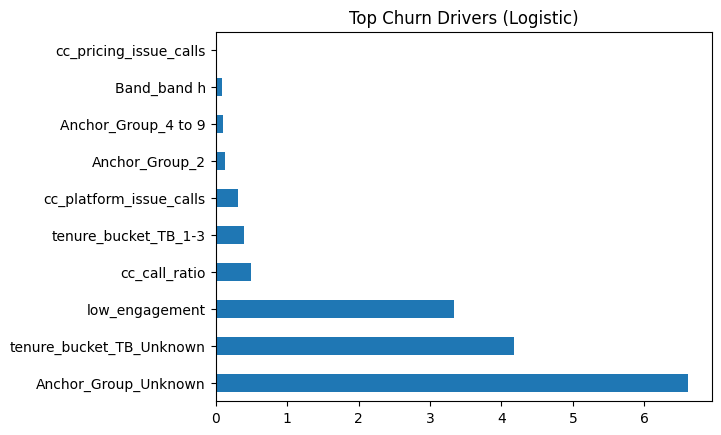

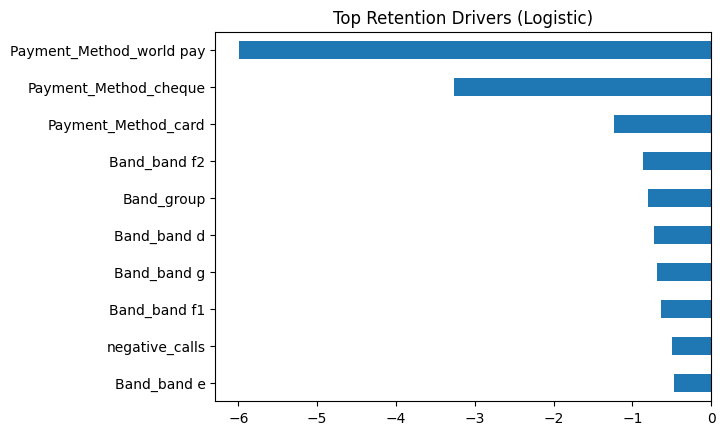

In [246]:
import matplotlib.pyplot as plt

coeffs_sorted.head(10).plot(kind='barh', title="Top Churn Drivers (Logistic)")
plt.show()

coeffs_sorted.tail(10).plot(kind='barh', title="Top Retention Drivers (Logistic)")
plt.show()

#### Logistic Regression Insights (Simple Explanation)

##### What increases churn

The model shows that the following factors strongly increase the chance of churn:

* Anchor_Group_Unknown
  Customers who are not clearly categorized or grouped have a very high chance of churning. This usually means the business does not understand or track them well.

* tenure_bucket_TB_Unknown
  If customer tenure is unknown or unclear, churn risk is high. This again points to data gaps or weak customer tracking.

* low_engagement
  Customers who are not actively engaging are very likely to churn. This is one of the most important and expected drivers.

* cc_call_ratio and issue-related calls
  Higher call ratios and platform/pricing issue calls increase churn. This suggests that customers who contact support more (especially with issues) are unhappy.

* tenure_bucket_TB_1-3
  New customers (first few months) are more likely to churn, which aligns with earlier findings.

* Anchor groups and certain bands
  Some customer segments show slightly higher churn, but their impact is smaller compared to engagement and renewal-related factors.


##### What reduces churn

The following factors reduce churn risk:

* Payment methods (card, cheque, world pay)
  Customers using structured or stable payment methods are less likely to churn. This shows that smooth and reliable payment experience improves retention.

* Band categories (d, e, f1, f2, g, etc.)
  Certain customer segments are more stable and less likely to churn. These are likely well-established or high-value users.

* Band_group
  Being part of a defined group reduces churn, meaning proper segmentation helps retention.

* negative_calls
  This appears as reducing churn, which may seem unexpected. It could mean that customers who raise issues are still engaged and trying to resolve problems instead of leaving immediately.



##### Overall understanding

From Logistic Regression, we can clearly see that churn is mainly driven by:

* Lack of engagement
* Lack of proper customer information or grouping
* Customer issues and dissatisfaction
* Early stage in customer lifecycle

At the same time, churn reduces when:

* Customers have stable payment behavior
* Customers belong to known segments
* Customers are more structured and trackable


##### Business interpretation

In simple terms:

Customers leave when the business does not understand them well, they are not engaged, or they face issues.

Customers stay when they are properly categorized, actively engaged, and have a smooth experience, especially in payments.


##### Recommendations

* Improve customer tracking and segmentation
  Avoid having "unknown" groups. Every customer should be clearly categorized.

* Focus on engagement
  Identify low-engagement users early and re-engage them through communication or offers.

* Improve support experience
  Reduce platform and pricing issues that lead to dissatisfaction.

* Strengthen onboarding
  New customers need extra attention in the first few months.

* Ensure smooth payment systems
  Stable and easy payment methods help retain customers.


##### Final note

These insights from Logistic Regression match closely with what we saw in XGBoost SHAP analysis.

This confirms that the identified churn drivers are reliable and consistent across models.
